# Self-funded sandwich attacks

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'mev_out').exists() and (REPO_ROOT.parent / 'mev_out').exists():
    REPO_ROOT = REPO_ROOT.parent
MEV_OUT = REPO_ROOT / 'mev_out'

fee = 0.0005

# load
df = pd.read_csv(MEV_OUT / f'sandwich_attacks_tidy_{fee}.csv')

# fee fraction and keep r = 1 - f
fee_bps = df.get('fee_bps', pd.Series(5.0, index=df.index)).astype(float)
f = fee_bps / 10_000.0
r = 1.0 - f

# decimals if present; otherwise default (common: token0=USDC 6, token1=WETH 18)
dec0 = (df.get('token0_decimals') or df.get('dec0') or pd.Series(6, index=df.index)).astype(int)
dec1 = (df.get('token1_decimals') or df.get('dec1') or pd.Series(18, index=df.index)).astype(int)

# pool deltas (absolute magnitudes)
fa0 = df['front_a0'].astype(float).abs().to_numpy()
ba0 = df['back_a0'].astype(float).abs().to_numpy()
fa1 = df['front_a1'].astype(float).abs().to_numpy()
ba1 = df['back_a1'].astype(float).abs().to_numpy()

front_dir = df['front_dir'].astype(str).to_numpy()
is_x2y = (front_dir == 'swap_x2y')

# Convert pool deltas -> trader-side inputs for the back leg (divide by r),
# and scale to token units using decimals.
# For x→y: compare token1:  back_a1 / r  vs  front_a1
# For y→x: compare token0:  back_a0 / r  vs  front_a0
diff_token1 = (ba1 / r) / (10.0 ** dec1) - (fa1 / (10.0 ** dec1))
diff_token0 = (ba0 / r) / (10.0 ** dec0) - (fa0 / (10.0 ** dec0))

# pick the right diff per row
diff_tokens = np.where(is_x2y, diff_token1, diff_token0)

# tolerances: a small relative tolerance + a decimals-based absolute dust
rtol = 2e-6
atol_token1 = 5.0 * (10.0 ** (-dec1))    # e.g., ~5e-18 for 18-dec tokens
atol_token0 = 5.0 * (10.0 ** (-dec0))    # e.g., ~5e-6 for 6-dec tokens
atol = np.where(is_x2y, atol_token1, atol_token0)

is_self_funded = np.isclose(diff_tokens, 0.0, rtol=rtol, atol=atol)

filtered_df = df[is_self_funded].copy()
filtered_df.to_csv(MEV_OUT / f'sandwich_attacks_tidy_self_funded_{fee}.csv', index=False)

print(f'Saved {len(filtered_df)} self-funded sandwich attacks (out of {len(df)} total).')


Saved 4 self-funded sandwich attacks (out of 2505 total).


# Comparison of MEV strategies

Calculating JIT profits...
Calculating Back-run profits...
Calculating Sandwich profits (this may take a moment)...


  0%|          | 0/1000 [00:00<?, ?it/s]

Calculating Mixed JIT+Sandwich profits (this will be slow)...


  0%|          | 0/1000 [00:00<?, ?it/s]

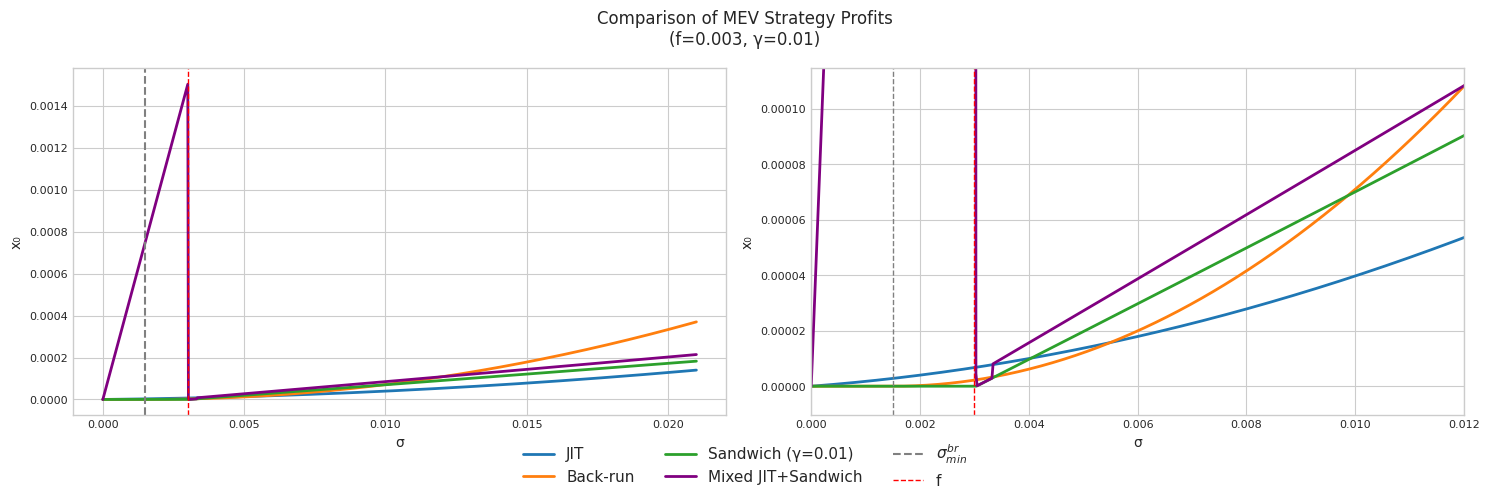

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, brute
from tqdm.notebook import tqdm
import warnings

# Suppress runtime warnings that can occur in optimization
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ======================================================================
# SECTION 1: PROFIT AND CONSTRAINT FUNCTIONS FOR EACH STRATEGY
# ======================================================================

# --- 1.1 JIT ---
# def calculate_jit_profit_old(sigma: np.ndarray, f: float) -> np.ndarray:
#     """Calculates the JIT bribe ceiling (normalized profit)."""
#     return sigma * f

# --- 1.1 JIT ---  (replaces the old fee-only version)
def calculate_jit_profit(sigma: np.ndarray, f: float, r: float, alpha: float) -> np.ndarray:
    """
    JIT normalized profit including LP inventory change (Section 3.1, Eq. (11), normalized by x0):
        π_JIT = (α/(1+α)) * σ*f + (α/(1+α)) * r*σ - α*r*σ / (1 + α + r*σ)
    """
    sigma = np.asarray(sigma, dtype=float)
    a = float(alpha)
    # guard rails
    sigma = np.where(sigma > 0, sigma, 0.0)
    if a <= 0:
        return np.zeros_like(sigma)
    return (a/(1.0+a))*sigma*(f + r) - (a*r*sigma)/(1.0 + a + r*sigma)


# --- 1.2 Back-run ---
def calculate_backrun_profit(sigma: np.ndarray, r: float) -> np.ndarray:
    """Calculates the optimal back-run profit (normalized). From Eq. (15)."""
    u = 1.0 + r * sigma
    profit = ((np.sqrt(r) * u - 1.0)**2) / (r * u)
    
    # Profit is only viable above a minimum sigma. From Eq. (13).
    sigma_min = (1.0 / np.sqrt(r) - 1.0) / r
    profit[sigma < sigma_min] = 0.0
    return profit

# --- 1.3 Classical Sandwich ---
def sandwich_profit_normalized(epsilon: float, sigma: float, r: float) -> float:
    """Normalized profit for a given epsilon and sigma. From Eq. (29)."""
    if epsilon <= 0: return 0.0
    num = r**2 * epsilon * (1 + r*epsilon + r*sigma)**2
    den = (1 + r*epsilon) + r**2 * epsilon * (1 + r*epsilon + r*sigma)
    if den == 0: return -epsilon
    return num / den - epsilon

def calculate_sandwich_profit(sigma: float, r: float, gamma: float) -> float:
    """Finds the optimal sandwich profit for a given sigma."""
    # Constraint: epsilon <= epsilon_max. From Eq. (27).
    try:
        root_term = np.sqrt((r * sigma)**2 + 4 * (1 + r * sigma) / (1 - gamma))
        eps_max = (1/r) * ((-r * sigma + root_term) / 2.0 - 1.0)
    except ValueError:
        eps_max = 0.0

    if eps_max <= 0:
        return 0.0
    
    # Numerically find the epsilon that maximizes profit up to eps_max
    # We use a simple grid search (brute force) for robustness.
    eps_grid = np.linspace(0, eps_max, 100)
    profits = [sandwich_profit_normalized(eps, sigma, r) for eps in eps_grid]
    return np.max(profits) if profits else 0.0

# --- 1.4 Mixed (JIT+Sandwich) ---
def calculate_theta_self_funded(epsilon: float, alpha: float, sigma: float, r: float) -> float:
    """Calculates theta for the self-funded case (scalar form)."""
    denom_epsilon = 1.0 + r * epsilon
    if denom_epsilon == 0.0:
        return 0.0

    theta_fr = r / denom_epsilon
    denom = denom_epsilon * (1.0 + alpha) + r * sigma

    if denom == 0.0:
        correction = 0.0
    else:
        correction = (alpha * sigma) / denom

    theta = theta_fr * (epsilon - correction)
    return max(0.0, theta)


def calculate_epsilon_max_jit(sigma: float, gamma: float, r: float, alpha: float) -> float:
    """Calculates the slippage constraint for the mixed strategy. From Eq. (44)."""
    if gamma >= 1.0: return float('inf')
    try:
        root = np.sqrt((r*sigma)**2 + 4*(1+alpha)**2*(1+r*sigma)/(1-gamma))
        eps_max = (1/r) * ((-r*sigma + root) / (2*(1+alpha)) - 1)
        return max(0.0, eps_max)
    except ValueError: return 0.0

def mixed_objective_function(x: np.ndarray, sigma: float, r: float) -> float:
    """The objective function with a stabilized denominator."""
    epsilon, alpha = x
    
    if epsilon < 0 or alpha < 0:
        return 1e9

    theta = calculate_theta_self_funded(epsilon, alpha, sigma, r)
    
    # Numerator of the main profit term
    term1_num_base = (1 + r*epsilon)*(1 + alpha) + r*sigma
    term1_num = term1_num_base**2 * r * theta
    
    # Denominator of the main profit term
    term1_den_base = (1 + alpha) + term1_num_base * r * theta
    term1_den = (1 + alpha) * term1_den_base
    
    # --- STABILIZATION FIX ---
    # Add a small constant to prevent division by zero or near-zero
    stabilizer = 1e-12
    
    if abs(term1_den) < stabilizer:
        pi_sand = -epsilon
    else:
        pi_sand = term1_num / (term1_den + stabilizer) - epsilon
        
    pi_jit_inv = (alpha * sigma) / (alpha + 1)
    
    profit = pi_sand + pi_jit_inv
    
    return -profit

def mixed_constraint_func(x: np.ndarray, sigma: float, r: float, gamma: float) -> float:
    """Constraint function epsilon <= epsilon_max."""
    epsilon, alpha = x
    return calculate_epsilon_max_jit(sigma, gamma, r, alpha) - epsilon

# Assume all other functions (objective, theta calculation, etc.) are defined

def backrun_constraint_func(x: np.ndarray, sigma: float, r: float) -> float:
    """
    Inequality constraint: theta > 0.
    The solver requires the form g(x) >= 0, so we return theta - epsilon, where epsilon is a small positive value.
    """
    epsilon, alpha = x
    # This is the same self-funded theta calculation used in the objective function
    theta = calculate_theta_self_funded(epsilon, alpha, sigma, r)
    return theta - 1e-12  # Ensure theta is strictly greater than 0

def calculate_mixed_profit(sigma: float, r: float, gamma: float) -> float:
    """Finds the optimal mixed strategy profit with the added theta constraint."""
    bounds = [(1e-12, None), (0, ALPHA_MAX)]
    
    # --- ADD THE NEW CONSTRAINT ---
    # Now we have two constraints for the solver
    constraints = [
        {'type': 'ineq', 'fun': mixed_constraint_func, 'args': (sigma, r, gamma)},
        {'type': 'ineq', 'fun': backrun_constraint_func, 'args': (sigma, r)}
    ]
    
    result = minimize(
        mixed_objective_function, 
        x0=[0.001, 0], 
        args=(sigma, r),
        method='SLSQP', 
        bounds=bounds,
        constraints=constraints, # Pass the updated list of constraints
        options={'ftol': 1e-10, 'maxiter': 200}
    )

    # Extract parameter
    epsilon_opt, alpha_opt = result.x
    return -result.fun, [epsilon_opt, alpha_opt]  if result.success else 0.0

# ======================================================================
# SECTION 2: COMPUTATION AND PLOTTING
# ======================================================================

# --- Model Parameters from Figure 5 ---
F_FEE = 0.003  # Uniswap fee rate f
R_VAL = 1.0 - F_FEE  # Net input rate r = 1-f
GAMMA_VAL = 0.01  # Victim slippage tolerance gamma = 1%
ALPHA_MAX = 1
ALPHA_JIT = 1

# --- Create a range of sigma values to plot ---
sigma_range = np.linspace(0.0000, 0.021, 1000)

# --- Calculate profits for each strategy ---
print("Calculating JIT profits...")
jit_profits = calculate_jit_profit(sigma_range, F_FEE, R_VAL, ALPHA_JIT)

print("Calculating Back-run profits...")
backrun_profits = calculate_backrun_profit(sigma_range, R_VAL)

print("Calculating Sandwich profits (this may take a moment)...")
sandwich_profits = [calculate_sandwich_profit(s, R_VAL, GAMMA_VAL) for s in tqdm(sigma_range)]

print("Calculating Mixed JIT+Sandwich profits (this will be slow)...")
mixed_profits = [calculate_mixed_profit(s, R_VAL, GAMMA_VAL)[0] for s in tqdm(sigma_range)]

# --- Generate the Plot ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Scale profits
Y_SCALE = 1

# --- Left subplot ---
ax[0].plot(sigma_range, np.array(jit_profits), label='JIT', linewidth=2)
ax[0].plot(sigma_range, np.array(backrun_profits), label='Back-run', linewidth=2)
ax[0].plot(sigma_range, np.array(sandwich_profits), label=f'Sandwich (γ={GAMMA_VAL})', linewidth=2)
ax[0].plot(sigma_range, np.array(mixed_profits), label='Mixed JIT+Sandwich', color='purple', linewidth=2)

sigma_min_br = (1.0 / np.sqrt(R_VAL) - 1.0) / R_VAL
ax[0].axvline(sigma_min_br, color='grey', linestyle='--', linewidth=1.5, label=r'$σ_{min}^{br}$')
ax[0].axvline(F_FEE, color='red', linestyle='--', linewidth=1, label='f')
ax[0].set_xlabel('σ', fontsize=10)
ax[0].set_ylabel('x₀', fontsize=10)
ax[0].tick_params(axis='both', which='major', labelsize=8)

# --- Right subplot ---
ax[1].plot(sigma_range, np.array(jit_profits), linewidth=2)
ax[1].plot(sigma_range, np.array(backrun_profits), linewidth=2)
ax[1].plot(sigma_range, np.array(sandwich_profits), linewidth=2)
ax[1].plot(sigma_range, np.array(mixed_profits), color='purple', linewidth=2)

ax[1].axvline(sigma_min_br, color='grey', linestyle='--', linewidth=1)
ax[1].axvline(F_FEE, color='red', linestyle='--', linewidth=1)

ax[1].set_xlabel('σ', fontsize=10)
ax[1].set_ylabel('x₀', fontsize=10)
ax[1].set_xlim(0, 0.0120)
ax[1].set_ylim(-0.00001045, 0.0001145)
ax[1].tick_params(axis='both', which='major', labelsize=8)

# --- One legend for all subplots ---
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='lower center',
           ncol=3,
           fontsize=11,
           frameon=False)

plt.suptitle(f'Comparison of MEV Strategy Profits\n(f={F_FEE}, γ={GAMMA_VAL})', fontsize=12)
plt.tight_layout(rect=[0, 0.07, 1, 1])  # 0.07 leaves space below
# Alternatively: plt.subplots_adjust(bottom=0.18)

plt.savefig(f'mev_out/profits_{F_FEE}.pdf', dpi=300, bbox_inches='tight')
plt.show()

Liquidity shared for JIT: 0.9090909090909091
Calculating JIT profits...
Calculating Back-run profits...
Calculating Sandwich profits (this may take a moment)...


  0%|          | 0/100 [00:00<?, ?it/s]

Calculating Mixed JIT+Sandwich profits (this will be slow)...


  0%|          | 0/100 [00:00<?, ?it/s]

Calculating JIT profits...
Calculating Back-run profits...
Calculating Sandwich profits (this may take a moment)...


...

  0%|          | 0/100 [00:00<?, ?it/s]

Calculating JIT profits...
Calculating Back-run profits...
Calculating Sandwich profits (this may take a moment)...


  0%|          | 0/100 [00:00<?, ?it/s]

Calculating Mixed JIT+Sandwich profits (this will be slow)...


  0%|          | 0/100 [00:00<?, ?it/s]

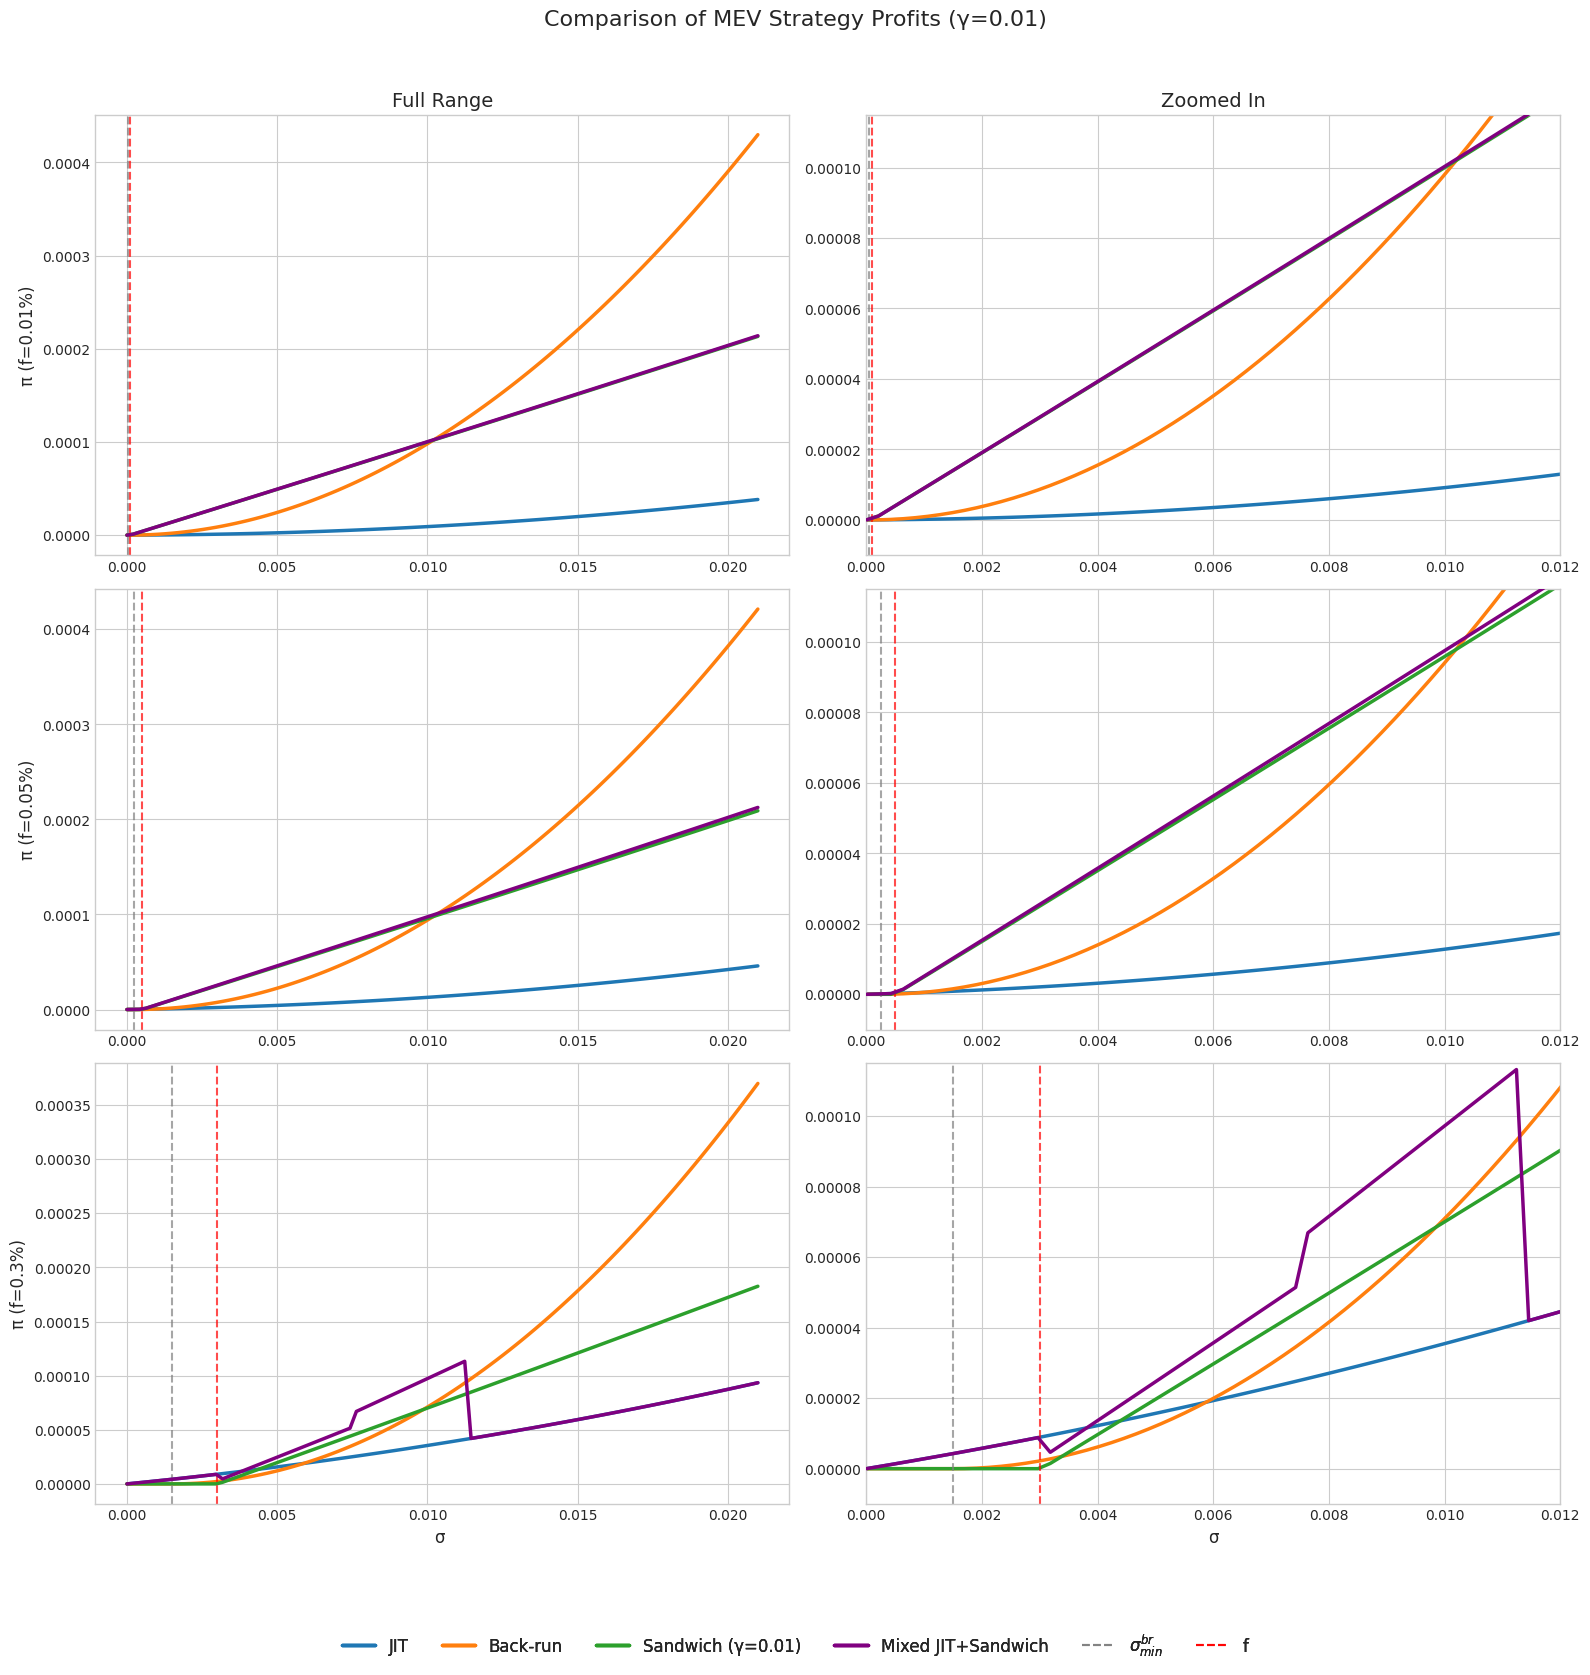

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from tqdm.notebook import tqdm
import warnings

# Suppress runtime warnings that can occur during optimization
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ======================================================================
# SECTION 1: PROFIT AND CONSTRAINT FUNCTIONS FOR EACH STRATEGY
# ======================================================================

# --- 1.1 JIT ---
def calculate_jit_profit(sigma: np.ndarray, f: float, r: float, alpha: float) -> np.ndarray:
    """
    Calculates the normalized JIT profit including LP inventory change.
    
    This is based on the derivation in Section 3.1, Eq. (11) of the paper, 
    normalized by the initial reserve x₀.
    π_JIT/x₀ = (α/(1+α)) * σ*f + (α/(1+α)) * r*σ - α*r*σ / (1 + α + r*σ)
    """
    sigma = np.asarray(sigma, dtype=float)
    a = float(alpha)
    # Ensure sigma is non-negative and alpha is positive
    sigma = np.where(sigma > 0, sigma, 0.0)
    if a <= 0:
        return np.zeros_like(sigma)
    
    # fees_earned = (a / (1.0 + a)) * sigma * f
    # inventory_change_x = (a / (1.0 + a)) * r * sigma
    inventory_change_y_value = (a * r * sigma) / (1.0 + a + r * sigma)
    
    # The formula can be simplified as shown in the original implementation
    return (a / (1.0 + a)) * sigma * (f + r) - inventory_change_y_value

# --- 1.2 Back-run ---
def calculate_backrun_profit(sigma: np.ndarray, r: float) -> np.ndarray:
    """Calculates the optimal back-run profit (normalized), from Eq. (21)."""
    sigma = np.asarray(sigma, dtype=float)
    u = 1.0 + r * sigma
    profit = ((np.sqrt(r) * u - 1.0)**2) / (r * u)
    
    # Profit is only viable above a minimum sigma, from Eq. (19).
    sigma_min = (1.0 / np.sqrt(r) - 1.0) / r
    profit[sigma < sigma_min] = 0.0
    return profit

# --- 1.3 Classical Sandwich ---
def sandwich_profit_normalized(epsilon: float, sigma: float, r: float) -> float:
    """Normalized profit for a given epsilon and sigma, from Eq. (35)."""
    if epsilon <= 1e-9: return 0.0
    num = r**2 * epsilon * (1.0 + r*epsilon + r*sigma)**2
    den = (1.0 + r*epsilon) + r**2 * epsilon * (1.0 + r*epsilon + r*sigma)
    if abs(den) < 1e-12: return -epsilon
    return num / den - epsilon

def calculate_sandwich_profit(sigma: float, r: float, gamma: float) -> float:
    """Finds the optimal sandwich profit for a given sigma."""
    # Constraint: epsilon <= epsilon_max, from Eq. (33).
    try:
        # Protect against negative values inside sqrt for gamma >= 1
        sqrt_inner = (r * sigma)**2 + 4.0 * (1.0 + r * sigma) / (1.0 - gamma)
        if sqrt_inner < 0:
             eps_max = 0.0
        else:
            root_term = np.sqrt(sqrt_inner)
            eps_max = (1.0/r) * ((-r * sigma + root_term) / 2.0 - 1.0)
    except (ValueError, ZeroDivisionError):
        eps_max = 0.0

    if eps_max <= 0:
        return 0.0
    
    # Numerically find the epsilon that maximizes profit up to eps_max
    # We use a simple grid search (brute force) for robustness.
    eps_grid = np.linspace(0, eps_max, 100)
    profits = [sandwich_profit_normalized(eps, sigma, r) for eps in eps_grid]
    return np.max(profits) if profits else 0.0

# --- 1.4 Mixed (JIT+Sandwich) ---
def calculate_theta_self_funded(epsilon: float, alpha: float, sigma: float, r: float) -> float:
    """Calculates theta for the self-funded case, from Eq. (58)."""
    if epsilon <= 0 or alpha < 0: return 0.0
    
    denom_epsilon = 1.0 + r * epsilon
    theta_fr_component = r / denom_epsilon

    denom_correction = denom_epsilon * (1.0 + alpha) + r * sigma
    if abs(denom_correction) < 1e-12:
        return 0.0
        
    correction = (alpha * sigma) / denom_correction
    theta = theta_fr_component * (epsilon - correction)
    return theta

def calculate_epsilon_max_jit(sigma: float, gamma: float, r: float, alpha: float) -> float:
    """Calculates the slippage constraint for the mixed strategy, from Eq. (49)."""
    if gamma >= 1.0: return float('inf')
    try:
        sqrt_inner = (r*sigma)**2 + 4.0*(1.0+alpha)**2 * (1.0+r*sigma) / (1.0-gamma)
        if sqrt_inner < 0: return 0.0
        root = np.sqrt(sqrt_inner)
        eps_max = (1.0/r) * ((-r*sigma + root) / (2.0*(1.0+alpha)) - 1.0)
        return max(0.0, eps_max)
    except (ValueError, ZeroDivisionError): 
        return 0.0

def mixed_objective_function(x: np.ndarray, sigma: float, r: float) -> float:
    """The objective function to be MINIMIZED (returns negative profit)."""
    epsilon, alpha = x[0], x[1]
    
    # Parameters must be positive
    if epsilon < 1e-9 or alpha < 0:
        return 1e9 # Return a large value for invalid parameters

    theta = calculate_theta_self_funded(epsilon, alpha, sigma, r)
    
    # Sandwich profit component
    term1_num_base = (1.0 + r*epsilon)*(1.0 + alpha) + r*sigma
    term1_num = term1_num_base**2 * r * theta
    term1_den_base = (1.0 + alpha) + term1_num_base * r * theta
    term1_den = (1.0 + alpha) * term1_den_base
    stabilizer = 1e-12
    
    pi_sand = (term1_num / (term1_den + stabilizer)) - epsilon if abs(term1_den) > stabilizer else -epsilon
        
    # JIT profit component (simplified in user code, follow that for consistency)
    pi_jit_inv = (alpha * sigma) / (alpha + 1.0)
    
    profit = pi_sand + pi_jit_inv
    
    return -profit

def mixed_constraint_func(x: np.ndarray, sigma: float, r: float, gamma: float) -> float:
    """Constraint function: epsilon <= epsilon_max. For solver: g(x) >= 0."""
    epsilon, alpha = x[0], x[1]
    return calculate_epsilon_max_jit(sigma, gamma, r, alpha) - epsilon

def calculate_mixed_profit(sigma: float, r: float, gamma: float, f: float) -> tuple[float, list[float]]:
    """
    Finds the optimal profit for a mixed strategy, falling back to pure JIT if no back-run is viable.
    
    This function first attempts to find the optimal parameters (epsilon, alpha) for a 
    combined Sandwich+JIT attack. After the optimization, it checks if the resulting 
    back-run size ('theta_self') is positive.

    - If theta_self > 0, the mixed strategy is valid, and its calculated profit is returned.
    - If theta_self <= 0 or the optimization fails, it signifies that a sandwich component
      is not feasible or profitable. In this case, the function reverts to calculating the
      profit of a pure JIT attack.
    """
    bounds = [(1e-9, None), (1e-9, ALPHA_MAX)]
    constraints = [{'type': 'ineq', 'fun': mixed_constraint_func, 'args': (sigma, r, gamma)}]
    
    result = minimize(
        mixed_objective_function, 
        x0=[1e-6, 0.5], 
        args=(sigma, r),
        method='SLSQP', 
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-10, 'maxiter': 200}
    )

    if result.success:
        epsilon_opt, alpha_opt = result.x
        theta_opt = calculate_theta_self_funded(epsilon_opt, alpha_opt, sigma, r)
        
        # If theta is positive, the mixed strategy is valid.
        if theta_opt > 1e-9:
            profit = -result.fun
            params = [epsilon_opt, alpha_opt]
            return profit, params
    
    # --- Fallback Case ---
    # If optimization failed OR theta_opt <= 0, fall back to pure JIT.
    # For pure JIT, epsilon is 0 and alpha is maximized to capture fees.
    jit_profit_val = calculate_jit_profit(np.array([sigma]), f, r, alpha=ALPHA_JIT)[0]
    params = [0.0, ALPHA_JIT]
    
    return jit_profit_val, params


# ======================================================================
# SECTION 2: COMPUTATION AND PLOTTING
# ======================================================================

# --- Model Parameters from the paper's Figure 7 ---
# F_FEE = 0.0001      # Uniswap fee rate f
# R_VAL = 1.0 - F_FEE  # Net input rate r = 1-f
GAMMA_VAL = 0.01   # Victim slippage tolerance gamma = 1%
ALPHA_MAX = 10.0    # Maximum alpha for JIT liquidity
ALPHA_JIT = 10.0    # Alpha used for pure JIT calculation

print(f"Liquidity shared for JIT: {ALPHA_MAX/(ALPHA_MAX +1)}")

# --- Generate the Plot ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(3, 2, figsize=(16, 16))
for i, F_FEE in enumerate([0.0001, 0.0005, 0.003]):
    R_VAL = 1.0 - F_FEE

    # --- Create a range of sigma values to plot ---
    sigma_range = np.linspace(0.0, 0.021, 100) # Reduced points for faster testing

    # --- Calculate profits for each strategy ---
    print("Calculating JIT profits...")
    jit_profits = calculate_jit_profit(sigma_range, F_FEE, R_VAL, ALPHA_JIT)

    print("Calculating Back-run profits...")
    backrun_profits = calculate_backrun_profit(sigma_range, R_VAL)

    print("Calculating Sandwich profits (this may take a moment)...")
    sandwich_profits = [calculate_sandwich_profit(s, R_VAL, GAMMA_VAL) for s in tqdm(sigma_range)]

    print("Calculating Mixed JIT+Sandwich profits (this will be slow)...")
    # Note the addition of F_FEE to the function call
    mixed_results = [calculate_mixed_profit(s, R_VAL, GAMMA_VAL, F_FEE) for s in tqdm(sigma_range)]
    mixed_profits = [res[0] for res in mixed_results]

    # --- Left subplot (Full Range) ---
    axs[i,0].plot(sigma_range, jit_profits, label='JIT', linewidth=2.5)
    axs[i,0].plot(sigma_range, backrun_profits, label='Back-run', linewidth=2.5)
    axs[i,0].plot(sigma_range, sandwich_profits, label=f'Sandwich (γ={GAMMA_VAL})', linewidth=2.5)
    axs[i,0].plot(sigma_range, mixed_profits, label='Mixed JIT+Sandwich', color='purple', linewidth=2.5, zorder=5)

    sigma_min_br = (1.0 / np.sqrt(R_VAL) - 1.0) / R_VAL
    axs[i,0].axvline(sigma_min_br, color='grey', linestyle='--', linewidth=1.5, label=r'$\sigma_{min}^{br}$', alpha=0.7)
    axs[i,0].axvline(F_FEE, color='red', linestyle='--', linewidth=1.5, label='f', alpha=0.7)
    axs[i,0].set_ylabel(f'π (f={F_FEE*100}%)', fontsize=12)
    axs[i,0].tick_params(axis='both', which='major', labelsize=10)

    # --- Right subplot (Zoomed In) ---
    axs[i,1].plot(sigma_range, jit_profits, linewidth=2.5)
    axs[i,1].plot(sigma_range, backrun_profits, linewidth=2.5)
    axs[i,1].plot(sigma_range, sandwich_profits, linewidth=2.5)
    axs[i,1].plot(sigma_range, mixed_profits, color='purple', linewidth=2.5, zorder=5)
    axs[i,1].axvline(sigma_min_br, color='grey', linestyle='--', linewidth=1.5, alpha=0.7)
    axs[i,1].axvline(F_FEE, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

    axs[i,1].set_xlim(0, 0.012)
    axs[i,1].set_ylim(-0.00001, 0.000115)
    axs[i,1].tick_params(axis='both', which='major', labelsize=10)

    # --- Common Legend ---
    handles, labels = axs[i,0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=12, bbox_to_anchor=(0.5, -0.02))

    fig.suptitle(f'Comparison of MEV Strategy Profits (γ={GAMMA_VAL})', fontsize=16, y=1.02)

axs[i,0].set_xlabel('σ ', fontsize=12)
axs[i,1].set_xlabel('σ', fontsize=12)
axs[0,0].set_title('Full Range', fontsize=14)
axs[0,1].set_title('Zoomed In', fontsize=14)
plt.savefig(f'mev_out/profits_comparison.pdf', dpi=300, bbox_inches='tight')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

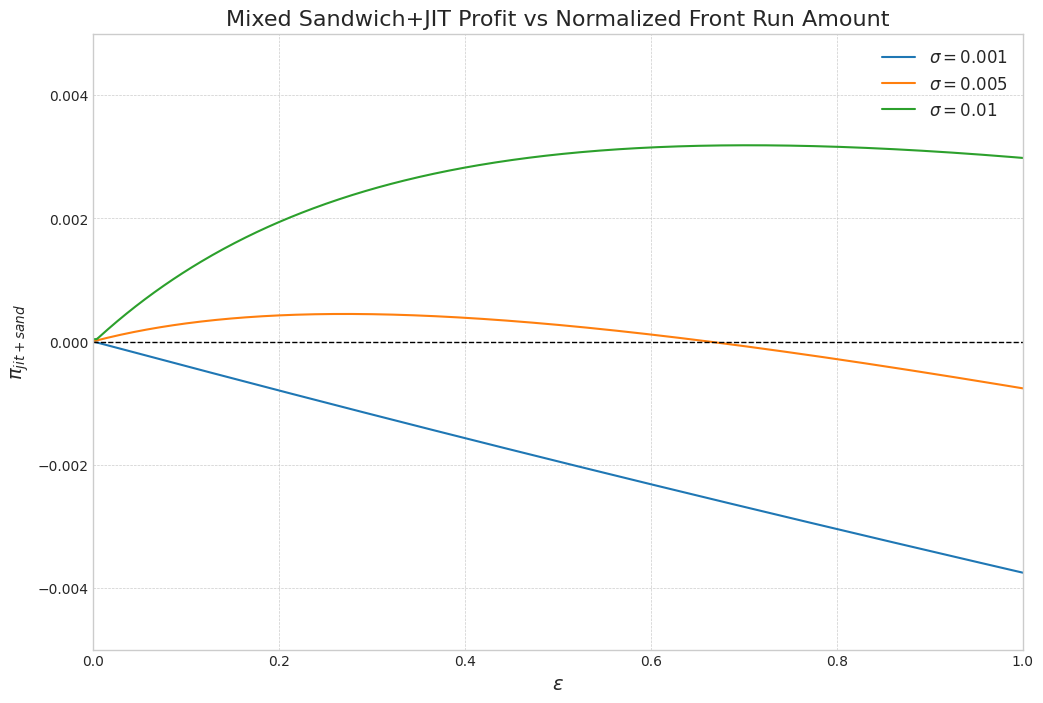

--- Verification Examples ---
Scenario 1: ε=0.01, σ=0.01 (Expect JIT Fallback)
Calculated Profit π = 0.000118
Pure JIT Profit   = 0.000040 (Should match)


Scenario 2: ε=0.5, σ=0.005 (Expect Mixed Strategy)
Calculated Profit π = 0.000271


In [55]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Union

# --- 1. Set up parameters and style ---
# Use a professional style for the plot
plt.style.use('seaborn-v0_8-whitegrid')

# Fixed model parameters
f: float = 0.003
r: float = 1 - f
alpha: float = 1.0

# Independent variable: fraction of informed flow
epsilon: np.ndarray = np.linspace(0, 1, 500)

# Volatility scenarios (normalized victim swap size)
sigmas: list[float] = [0.001, 0.005, 0.01]


# --- 2. Define the profit functions ---

def calculate_jit_profit_only(
    sigma: Union[np.ndarray, float],
    alpha: float,
    f: float,
    r: float
) -> Union[np.ndarray, float]:
    """
    Calculates the profit of a pure JIT strategy.

    This serves as the fallback option when the sandwich component of the
    mixed strategy is not profitable (i.e., when theta_self <= 0).
    The formula is derived from Section 3.1, Eq. (11) of your paper.

    Args:
        sigma: Normalized victim swap amount.
        alpha: Multiplier of the reserves to add in the mint.
        f: The pool's fee tier.
        r: 1 - f (net input rate).

    Returns:
        The calculated profit of a pure JIT attack.
    """
    # Ensure sigma and alpha are positive
    sigma = np.maximum(0, sigma)
    if alpha <= 0:
        return np.zeros_like(sigma)
    
    # Simplified profit formula for pure JIT
    # π_JIT = (α/(1+α)) * σ*f + (α/(1+α)) * r*σ - α*r*σ / (1 + α + r*σ)
    profit = (alpha / (1.0 + alpha)) * sigma * (f + r) - (alpha * r * sigma) / (1.0 + alpha + r * sigma)
    return profit


def calculate_profit(
    epsilon: Union[np.ndarray, float],
    sigma: float,
    alpha: float,
    f: float,
    r: float
) -> Union[np.ndarray, float]:
    """
    Calculates the combined Sandwich and JIT profit with rational fallback.

    This function implements the mixed strategy profit, but crucially checks if the
    back-run amount (theta_self) is positive. If not, it falls back to the
    profit of a pure JIT strategy, modeling a rational agent's decision.

    Args:
        epsilon: Normalized front run amount.
        sigma: Normalized victim swap amount.
        alpha: Multiplier of the reserves to add in the mint.
        f: The pool's fee tier.
        r: 1 - f (net input rate).

    Returns:
        The calculated profit, applying the economically rational fallback.
    """
    # First, calculate the self-selected order flow proportion (theta_self)
    theta_numerator = epsilon - (alpha * sigma) / ((1 + r * epsilon) * (1 + alpha) + r * sigma)
    theta_self = (r / (1 + r * epsilon)) * theta_numerator

    # --- Calculate the profit for the full mixed strategy ---
    common_term = (1 + r * epsilon) * (1 + alpha) + r * sigma
    pi_numerator = (common_term**2) * r * theta_self
    pi_denominator = (1 + alpha) * ((1 + alpha) + common_term * r * theta_self)
    
    # Handle potential division by zero
    pi_fraction = np.divide(
        pi_numerator,
        pi_denominator,
        out=np.zeros_like(pi_numerator, dtype=float),
        where=pi_denominator != 0
    )
    
    profit_mixed = pi_fraction - epsilon + (alpha * sigma) / (alpha + 1)
    
    # --- Calculate the fallback pure JIT profit ---
    # Since epsilon can be an array, we need an array of JIT profits of the same shape
    profit_jit = np.full_like(epsilon, calculate_jit_profit_only(sigma, alpha, f, r), dtype=float)

    # --- THE RATIONAL AGENT DECISION ---
    # If theta_self > 0, the mixed strategy is profitable.
    # Otherwise, the agent falls back to a pure JIT strategy.
    final_profit = np.where(theta_self > 0, profit_mixed, profit_jit)
    
    return final_profit

def epsilon_max_jit(sigma: float, gamma: float, r: float, alpha: float) -> float:
    """Calculates the maximum epsilon allowed for the mixed strategy."""
    if gamma >= 1.0: return float('inf')
    try:
        root = np.sqrt((r*sigma)**2 + 4*(1+alpha)**2*(1+r*sigma)/(1-gamma))
        eps_max = (1/r) * ((-r*sigma + root) / (2*(1+alpha)) - 1)
        return max(0.0, eps_max)
    except ValueError: return 0.0

# --- 3. Generate and plot the data ---
fig, ax = plt.subplots(figsize=(12, 8))

# Calculate and plot the profit for each sigma value
for sigma_val in sigmas:
    # Pass the fee 'f' to the main function now
    profit = calculate_profit(epsilon, sigma_val, alpha, f, r)
    ax.plot(epsilon, profit, label=f'$\\sigma = {sigma_val}$')

# --- 4. Finalize the plot ---
ax.set_xlabel('$\\varepsilon$ ', fontsize=14)
ax.set_ylabel('$\\pi_{jit+sand}$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Add a horizontal line at y=0 to indicate the break-even point
ax.axhline(0, color='black', linestyle='--', linewidth=1.0)

# Add a vertical line at epsilon_max for reference
# epsilon_max_val =  [epsilon_max_jit(sigmas[i], gamma=0.01, r=r, alpha=alpha) for i in range(len(sigmas))]
# for epsilon_max_val in epsilon_max_val:
#     ax.axvline(epsilon_max_val, linestyle='--', linewidth=1.0, label=r'$\varepsilon_{max}^{jit}$')

# Set plot limits for clarity
ax.set_xlim([0, 1])
ax.set_ylim([-0.005, 0.005]) # Adjusted for the new profit curves
ax.set_title('Mixed Sandwich+JIT Profit vs Normalized Front Run Amount', fontsize=16)

plt.show()

# --- 5. Small synthetic example for verification ---
# Check the profit for two scenarios
print("--- Verification Examples ---")
# Scenario 1: Epsilon is small, theta_self should be negative -> fallback to JIT
test_epsilon_1 = 0.01
test_sigma_1 = 0.01
profit_check_1 = calculate_profit(test_epsilon_1, test_sigma_1, alpha, f, r)
jit_profit_ref = calculate_jit_profit_only(test_sigma_1, alpha, f, r)
print(f"Scenario 1: ε={test_epsilon_1}, σ={test_sigma_1} (Expect JIT Fallback)")
print(f"Calculated Profit π = {profit_check_1:.6f}")
print(f"Pure JIT Profit   = {jit_profit_ref:.6f} (Should match)")

print("\n")

# Scenario 2: Epsilon is large, theta_self should be positive -> mixed strategy
test_epsilon_2 = 0.5
test_sigma_2 = 0.005
profit_check_2 = calculate_profit(test_epsilon_2, test_sigma_2, alpha, f, r)
print(f"Scenario 2: ε={test_epsilon_2}, σ={test_sigma_2} (Expect Mixed Strategy)")
print(f"Calculated Profit π = {profit_check_2:.6f}")

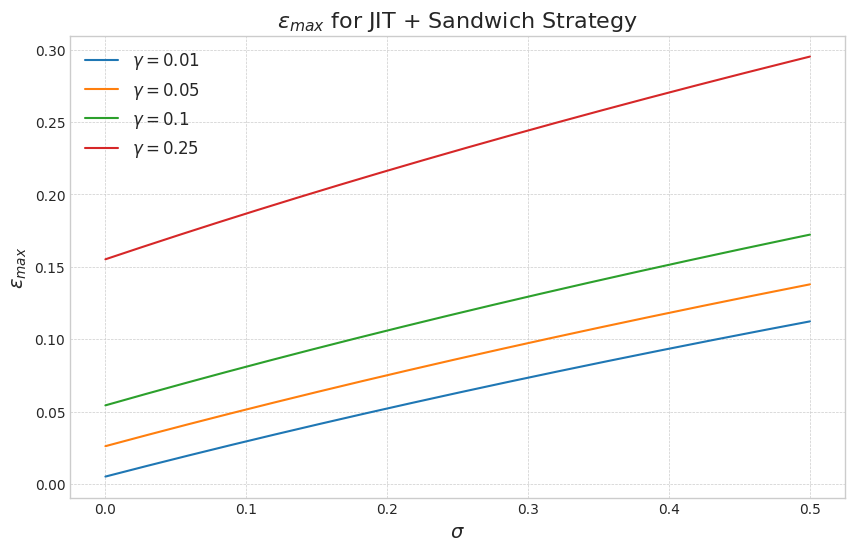

In [75]:
import numpy as np
import matplotlib.pyplot as plt

def epsilon_max_jit(sigma: np.ndarray, gamma: float, r: float, alpha: float) -> float:
    """Calculates the maximum epsilon allowed for the mixed strategy."""
    root = np.sqrt((r*sigma)**2 + 4*(1+alpha)**2*(1+r*sigma)/(1-gamma))
    eps_max = (1/r) * ((-r*sigma + root) / (2*(1+alpha)) - 1)
    return eps_max

ALPHA = 1
R = 0.997
GAMMAS = [0.01, 0.05, 0.1, 0.25]

sigma_values = np.linspace(0.0001, 0.5, 500)
epsilon_max_values = [epsilon_max_jit(sigma_values, gamma, R, ALPHA) for gamma in GAMMAS]

plt.figure(figsize=(10, 6))
for eps, gamma in zip(epsilon_max_values, GAMMAS):
    plt.plot(sigma_values, eps, label=rf'$\gamma={gamma}$')
plt.xlabel(r'$\sigma$', fontsize=14)
plt.ylabel(r'$\varepsilon_{max}$', fontsize=14)
plt.title(r'$\varepsilon_{max}$ for JIT + Sandwich Strategy', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig('mev_out/epsilon_max_jit_sand.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Regime transition in JIT+Sandwich strategy

🚀 Running optimization for FEE = 0.0001...
🚀 Running optimization for FEE = 0.0005...
🚀 Running optimization for FEE = 0.003...


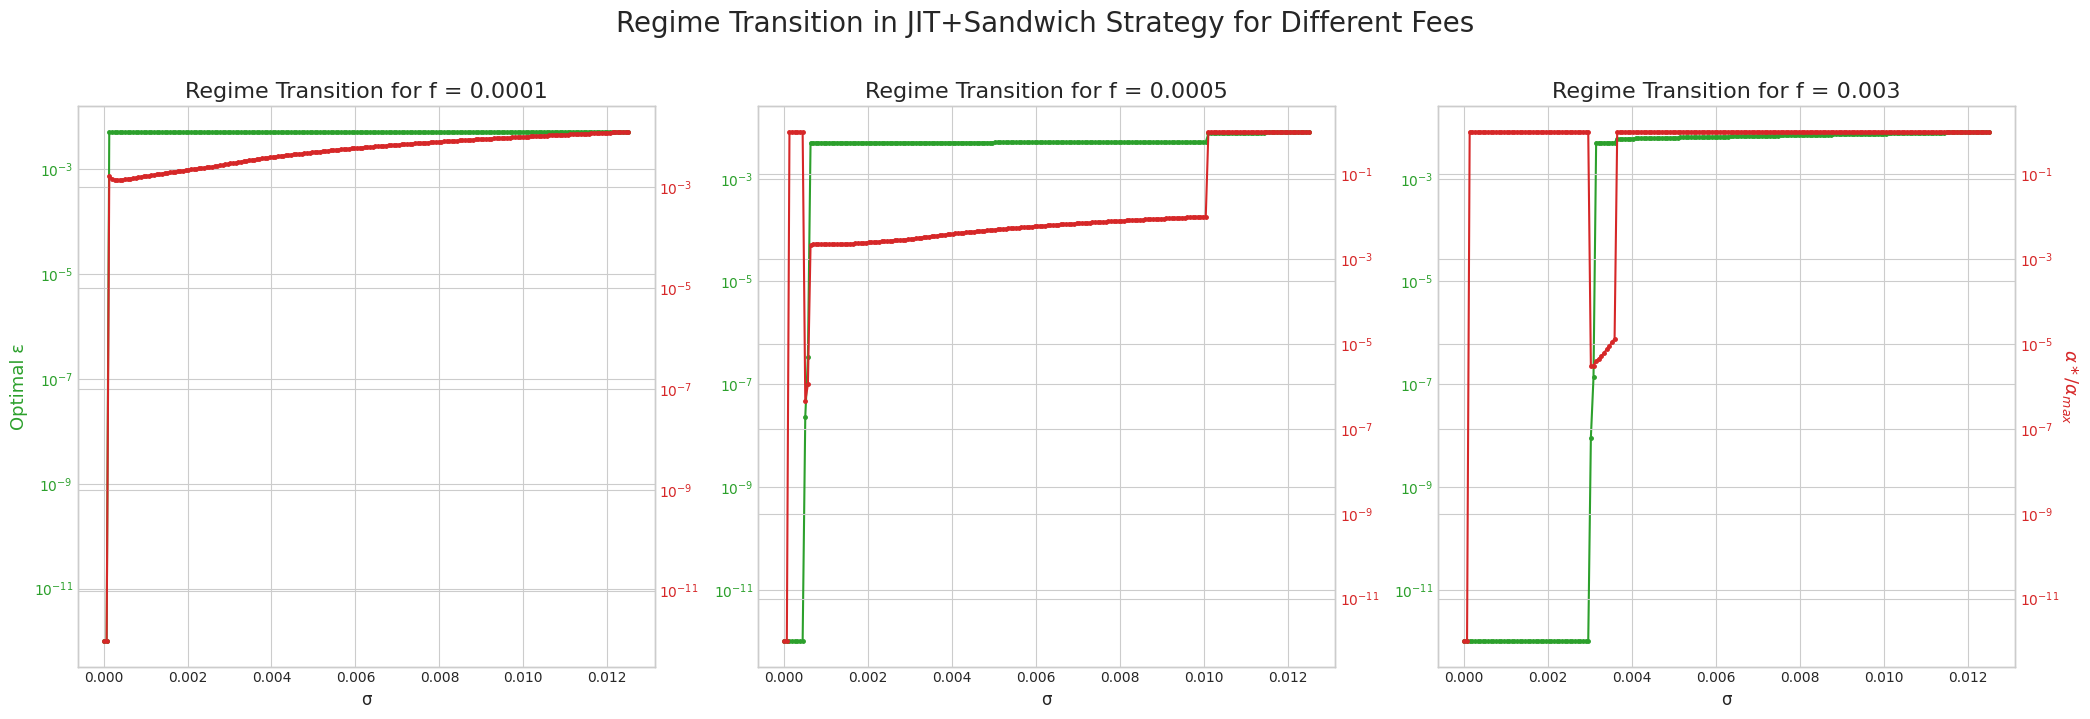

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings

# Suppress runtime warnings that can be distracting
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- Model Parameters ---
FEE_values = [0.0001, 0.0005, 0.003]
GAMMA_VAL = 0.01  # Victim slippage tolerance of 1%
ALPHA_MAX = 1

# --- Helper, Objective, and Constraint Functions ---

def calculate_theta_self_funded(epsilon: float, alpha: float, sigma: float, r: float) -> float:
    """
    Calculates theta for the self-funded case (scalar form).
    Theta represents the fraction of the back-run trade.
    """
    denom_epsilon = 1.0 + r * epsilon
    if denom_epsilon == 0.0:
        return 0.0

    theta_fr = r / denom_epsilon
    denom = denom_epsilon * (1.0 + alpha) + r * sigma

    if denom == 0.0:
        correction = 0.0
    else:
        correction = (alpha * sigma) / denom

    theta = theta_fr * (epsilon - correction)
    return max(0.0, theta)


def calculate_epsilon_max_jit(sigma: float, gamma: float, r: float, alpha: float) -> float:
    """
    Calculates the maximum sandwich size (epsilon) tolerated by the victim.
    This is derived from the victim's slippage constraint (gamma).
    """
    if gamma >= 1.0:
        return float('inf')
    try:
        # Derived from solving the quadratic equation for the slippage constraint
        root = np.sqrt((r * sigma)**2 + 4 * (1 + alpha)**2 * (1 + r * sigma) / (1 - gamma))
        eps_max = (1 / r) * ((-r * sigma + root) / (2 * (1 + alpha)) - 1)
        return max(0.0, eps_max)
    except ValueError:
        return 0.0

def mixed_objective_function(x: np.ndarray, sigma: float, r: float) -> float:
    """
    The objective function to maximize: sum of sandwich profit and JIT profit.
    We return the negative because scipy.optimize.minimize finds a minimum.
    """
    epsilon, alpha = x
    theta = calculate_theta_self_funded(epsilon, alpha, sigma, r)
    
    # Sandwich profit calculation
    term1_num_base = (1 + r * epsilon) * (1 + alpha) + r * sigma
    term1_num = term1_num_base**2 * r * theta
    term1_den_base = (1 + alpha) + term1_num_base * r * theta
    term1_den = (1 + alpha) * term1_den_base
    stabilizer = 1e-12  # To avoid division by zero
    
    pi_sand = term1_num / (term1_den + stabilizer) - epsilon if abs(term1_den) > stabilizer else -epsilon
    
    # JIT profit (from providing liquidity against the victim's trade)
    pi_jit_inv = (alpha * sigma) / (alpha + 1)
    
    return -(pi_sand + pi_jit_inv)

def slippage_constraint_func(x: np.ndarray, sigma: float, r: float, gamma: float) -> float:
    """
    Constraint function: ensures epsilon <= epsilon_max.
    The function must be >= 0 for the constraint to be satisfied.
    """
    epsilon, alpha = x
    return calculate_epsilon_max_jit(sigma, gamma, r, alpha) - epsilon

def backrun_constraint_func(x: np.ndarray, sigma: float, r: float) -> float:
    """
    Constraint function: ensures the back-run is profitable (theta >= 0).
    The function must be >= 0 for the constraint to be satisfied.
    """
    epsilon, alpha = x
    return calculate_theta_self_funded(epsilon, alpha, sigma, r)

# --- Main Optimization and Plotting Loop ---

# Set up the figure and subplots
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, len(FEE_values), figsize=(21, 7), sharey=False)

# Ensure 'axes' is always an iterable list, even if there's only one subplot
if len(FEE_values) == 1:
    axes = [axes]

# Loop through each fee value to run the optimization and plot the results
for i, FEE in enumerate(FEE_values):
    R_VAL = 1 - FEE
    sigma_values = np.linspace(0.00001, 0.0125, 200)
    optimal_epsilons = []
    optimal_alphas = []

    print(f"🚀 Running optimization for FEE = {FEE}...")
    for sigma in sigma_values:
        bounds = [(1e-12, None), (1e-12, ALPHA_MAX)]
        constraints = [
            {'type': 'ineq', 'fun': slippage_constraint_func, 'args': (sigma, R_VAL, GAMMA_VAL)},
            {'type': 'ineq', 'fun': backrun_constraint_func, 'args': (sigma, R_VAL)}
        ]
        
        # Run the numerical optimization
        result = minimize(
            mixed_objective_function, x0=[0, 0], args=(sigma, R_VAL),
            method='SLSQP', bounds=bounds, constraints=constraints,
            options={'ftol': 1e-10, 'maxiter': 200}
        )
        
        # Store results or NaNs if optimization fails
        if result.success:
            optimal_epsilons.append(result.x[0])
            optimal_alphas.append(result.x[1])
        else:
            optimal_epsilons.append(np.nan)
            optimal_alphas.append(np.nan)

    # Select the current subplot
    ax1 = axes[i]

    # Plot Optimal Epsilon (ε)
    color = 'tab:green'
    ax1.set_xlabel('σ', fontsize=12)
    if i == 0:  # Set y-label only for the first subplot to avoid clutter
        ax1.set_ylabel('Optimal ε', color=color, fontsize=13)
    ax1.plot(sigma_values, optimal_epsilons, color=color, marker='.', markersize=5, linestyle='-')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_yscale('log')
    ax1.set_title(f'Regime Transition for f = {FEE}', fontsize=16)

    # Create a second y-axis for Optimal Alpha (α)
    ax2 = ax1.twinx()
    color = 'tab:red'
    if i == len(FEE_values) - 1:  # Set y-label only for the last subplot
        ax2.set_ylabel(r'$\alpha*/\alpha_{max}$', color=color, fontsize=13, rotation=270, labelpad=15)
    ax2.plot(sigma_values, np.array(optimal_alphas)/ALPHA_MAX, color=color, marker='.', markersize=5, linestyle='-')
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.set_yscale('log')

# --- Final Figure Adjustments ---
fig.suptitle('Regime Transition in JIT+Sandwich Strategy for Different Fees', fontsize=20, y=1.02)
fig.tight_layout()

# Save the figure in multiple formats
plt.savefig('mev_out/regime_transition_subplots.pdf', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

# Gif of JIT+sandwich profit wrt $\varepsilon, \alpha$ and $\sigma$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import Normalize
from tqdm.notebook import tqdm
import warnings

# Suppress runtime warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- Model Parameters ---
FEE = 0.003
R_VAL = 1-FEE

# --- Helper and Profit Functions (Vectorized for plotting) ---

def calculate_theta_self_funded_vec(
    epsilon: np.ndarray, alpha: np.ndarray, sigma: float, r: float
) -> np.ndarray:
    """Vectorized calculation of theta for a grid of epsilon and alpha."""
    # Using np.newaxis for broadcasting
    epsilon = epsilon[np.newaxis, :]
    alpha = alpha[:, np.newaxis]
    
    theta_fr = r / (1 + r * epsilon)
    
    denominator = (1 + r * epsilon) * (1 + alpha) + r * sigma
    numerator = alpha * sigma
    
    theta = theta_fr * (epsilon - numerator/denominator)
    return np.maximum(0.0, theta)


def calculate_profit_surface(
    epsilon_grid: np.ndarray, alpha_grid: np.ndarray, sigma: float, r: float
) -> np.ndarray:
    """Calculates the profit pi over a 2D grid of epsilon and alpha."""
    theta_grid = calculate_theta_self_funded_vec(epsilon_grid[0, :], alpha_grid[:, 0], sigma, r)
    
    term1_num_base = (1 + r*epsilon_grid)*(1 + alpha_grid) + r*sigma
    term1_num = term1_num_base**2 * r * theta_grid
    
    term1_den_base = (1 + alpha_grid) + term1_num_base * r * theta_grid
    term1_den = (1 + alpha_grid) * term1_den_base
    
    pi_sand = np.divide(term1_num, term1_den, out=np.full_like(term1_num, -np.inf), where=term1_den!=0) - epsilon_grid
    
    pi_jit_inv = (alpha_grid * sigma) / (1 + alpha_grid)
    
    profit = pi_sand + pi_jit_inv
    return profit

# --- Animation Setup ---

# Create the grids for epsilon and alpha
epsilon_vec = np.linspace(0.001, 0.99, 500)
alpha_vec = np.linspace(0.001, 10, 500)
Epsilon_grid, Alpha_grid = np.meshgrid(epsilon_vec, alpha_vec)

# Create the sigma values for the animation frames
sigma_values = np.linspace(0.0001, 0.99, 500)

# --- Pre-calculate all profit surfaces to set a consistent color scale ---
print("Pre-calculating profit surfaces to set color scale...")
all_profits = [calculate_profit_surface(Epsilon_grid, Alpha_grid, s, R_VAL) for s in sigma_values]
# Find the maximum absolute profit value across all frames
abs_max_profit = np.nanmax(np.abs(all_profits))
# Create a normalization object to center the colormap at zero
norm = Normalize(vmin=-abs_max_profit, vmax=abs_max_profit)


# --- Set up the figure and 3D axis ---
fig = plt.figure(figsize=(13, 9))
ax = fig.add_subplot(111, projection='3d')
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='coolwarm'), ax=ax, label='π (Normalized Profit)', pad=0.1)

# --- Animation Update Function ---
pbar = tqdm(total=len(sigma_values), desc="Generating GIF frames")

def update(frame_index):
    """Update function for the animation."""
    sigma = sigma_values[frame_index]
    profit_surface = all_profits[frame_index]
    
    ax.clear()
    
    # Plot the 3D surface with the diverging colormap and normalized colors
    surf = ax.plot_surface(
        Epsilon_grid, Alpha_grid, profit_surface,
        cmap='coolwarm',  # Blue-white-red colormap
        norm=norm,        # Center the colormap at zero
        edgecolor='none'
    )
    
    # Formatting
    ax.set_title(f'JIT+Sandwich Normalized Profit Surface (π)\nσ = {sigma:.4f}', fontsize=16)
    ax.set_xlabel('ε (Front-run Size)', fontsize=12, labelpad=15)
    ax.set_ylabel('α (JIT Liquidity)', fontsize=12, labelpad=15)
    ax.set_zlabel('Profit π', fontsize=12, labelpad=15)
    ax.view_init(elev=30, azim=-120)
    ax.set_zlim(-abs_max_profit * 0.5, abs_max_profit * 1.1) # Set z-axis limit
    
    pbar.update(1)
    return surf,

# --- Create and Save the Animation ---
print("🚀 Creating colorized animation... This may take a minute.")
ani = FuncAnimation(fig, update, frames=len(sigma_values), blit=False)

try:
    ani.save(f'jit_sandwich_profit_3d_colorized_{FEE}.gif', writer=PillowWriter(fps=12))
    print(f"\n✅ Animation saved successfully as 'jit_sandwich_profit_3d_colorized_{FEE}.gif'")
except Exception as e:
    print(f"\n❌ Error saving animation: {e}")
    print("Please ensure you have 'Pillow' installed: pip install Pillow")

plt.close()

Pre-calculating profit surfaces to set color scale...


Generating GIF frames:   0%|          | 0/500 [00:00<?, ?it/s]

🚀 Creating colorized animation... This may take a minute.

✅ Animation saved successfully as 'jit_sandwich_profit_3d_colorized_0.003.gif'


In [17]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import imageio
import os
import shutil

def create_profit_animation():
    """
    Generates an animated GIF showing how the profit landscape changes with
    the sigma parameter.
    """
    # 1. Symbolic Setup
    epsilon, alpha, sigma, r = sp.symbols('varepsilon alpha sigma r', real=True, positive=True)
    theta_self_expr = (r / (1 + r * epsilon)) * (epsilon - (alpha * sigma) / ((1 + r * epsilon) * (1 + alpha) + r * sigma))
    T = (1 + r * epsilon) * (1 + alpha) + r * sigma
    numerator = (T**2) * r * theta_self_expr
    denominator = (1 + alpha) * ((1 + alpha) + T * r * theta_self_expr)
    pi_expr_full = (numerator / denominator) - epsilon + (alpha * sigma) / (alpha + 1)
    
    pi_numerical = sp.lambdify([alpha, epsilon, sigma, r], pi_expr_full, 'numpy')

    # 2. Define Parameters and Grids
    r_val = 0.997
    alpha_range = np.linspace(0.001, 1.0, 100)
    epsilon_range = np.linspace(0.001, 1, 100)
    A, E = np.meshgrid(alpha_range, epsilon_range)
    
    num_frames = 40
    sigma_values = np.linspace(0.0001, 0.0125, num_frames)

    # 3. Pre-calculate all Profit Data for a consistent color scale
    print("Pre-calculating all profit landscapes to determine color scale...")
    all_profits = [pi_numerical(A, E, s, r_val) for s in sigma_values]
    global_min = min(Z.min() for Z in all_profits)
    global_max = max(Z.max() for Z in all_profits)
    
    # 4. Generate and Save Each Frame
    frames_dir = 'animation_frames'
    if os.path.exists(frames_dir):
        shutil.rmtree(frames_dir)
    os.makedirs(frames_dir)
    
    print(f"Generating {num_frames} frames...")
    filenames = []
    for i, sigma_val in enumerate(sigma_values):
        Z_profit = all_profits[i]
        
        fig, ax = plt.subplots(figsize=(12, 8))
        norm = TwoSlopeNorm(vcenter=0, vmin=global_min, vmax=global_max)
        
        pcm = ax.pcolormesh(A, E, Z_profit, cmap='RdYlGn', norm=norm, shading='auto')
        fig.colorbar(pcm, label=r'Profit $\pi(\varepsilon, \alpha)$')

        CS = ax.contour(A, E, Z_profit, levels=[0], colors='black', linewidths=2)
        # ax.clabel(CS, inline=True, fontsize=10, fmt='π = 0', manual=[(0.5, 0.5)]) 

        ax.set_yscale('log')
        ax.set_title(r'Profit Landscape for $\sigma = {:.5f}$'.format(sigma_val), fontsize=18)
        ax.set_xlabel(r'$\alpha$', fontsize=14)
        ax.set_ylabel(r'$\varepsilon$', fontsize=14)

        plt.tight_layout()
        
        filename = os.path.join(frames_dir, f'frame_{i:03d}.png')
        filenames.append(filename)
        plt.savefig(filename, dpi=100)
        plt.close(fig)

    # 5. Create Animated GIF
    print("Stitching frames into an animated GIF...")
    with imageio.get_writer('profit_landscape_animation.gif', mode='I', duration=150, loop=0) as writer:
        for filename in filenames:
            image = imageio.imread(filename)
            writer.append_data(image)
    
    # 6. Clean Up
    # shutil.rmtree(frames_dir)
    print("\nAnimation saved as 'profit_landscape_animation.gif'")

if __name__ == '__main__':
    create_profit_animation()

Pre-calculating all profit landscapes to determine color scale...
Generating 40 frames...
Stitching frames into an animated GIF...


/tmp/ipykernel_309630/175340502.py:75: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)



Animation saved as 'profit_landscape_animation.gif'


# Back run amount wrt front run amount and LP inventory change

/tmp/ipykernel_1238/1067901779.py:125: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_dir = res.groupby("victim_dir", dropna=False).apply(fit_stats)


=== Overall ===
n: 499
corr_obs_hat: 0.9891520883546825
rmse: 6.820738771744019e+18
median_abs_pct_error: 0.00050024275626593
share_|BR|<|FR|: 0.9979959919839679
corr(alpha*v, |FR|-|BR|): 0.9902300820917668
ols_intercept: -9.796806397386374e-21
ols_slope: 1.0733134128499109

=== By victim direction ===
[x_to_y]
  n: 137
  corr_obs_hat: 0.9824538188534793
  rmse: 1.301731475185489e+19
  median_abs_pct_error: 0.0005002477699550436
  share_|BR|<|FR|: 1.0
  corr(alpha*v, |FR|-|BR|): 0.9304964768471049
  ols_intercept: -9.796806158512516e-21
  ols_slope: 1.0733134128499096
[y_to_x]
  n: 362
  corr_obs_hat: 0.9808842764299481
  rmse: 131556805950.592
  median_abs_pct_error: 0.0005002408349180067
  share_|BR|<|FR|: 0.9972375690607734
  corr(alpha*v, |FR|-|BR|): 0.851331582411332
  ols_intercept: -4790443671.3571205
  ols_slope: 1.0903038151470208


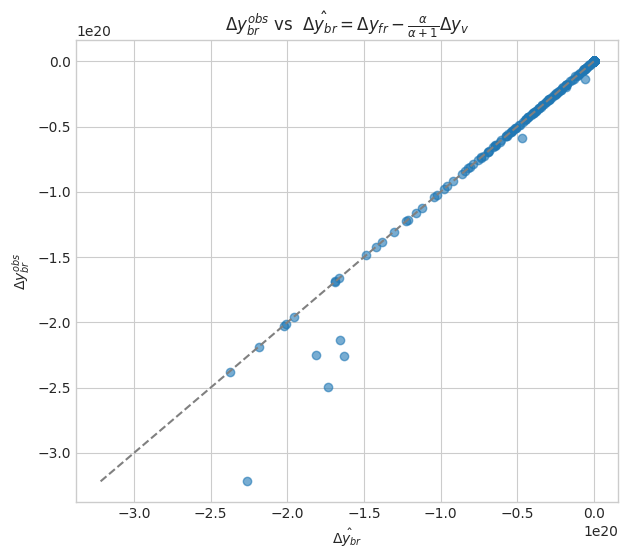

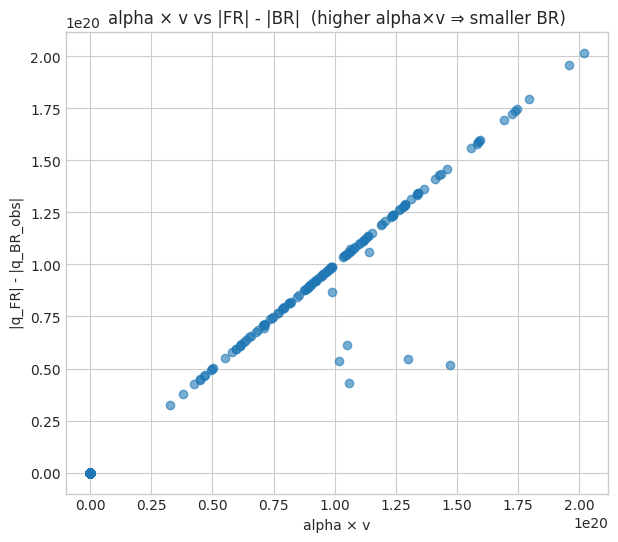

In [78]:
"""
JIT + Sandwich verification (both directions)

We test the identity:
    q_BR_hat = -(q_FR - alpha * v)

All amounts are measured in the victim’s *output* token.
Mapping by direction:
  - If victim_dir = x->y (token0 -> token1):
        q_FR     = - front_a1
        q_BR_obs = - back_a1
        v        = - S_net_token1
  - If victim_dir = y->x (token1 -> token0):
        q_FR     = - front_a0
        q_BR_obs = - back_a0
        v        = - S_net_token0

Alpha:
  alpha = attacker_liq_share
  (fallback if NaN/missing): alpha ≈ mint_amount / (L0 + mint_amount)

Outputs:
  - Overall fit stats + per-direction stats
  - Scatter: observed vs predicted BR
  - Scatter: (alpha * v) vs (|FR| - |BR|)
  - CSV with per-cycle results
"""

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Load data -------------------------------------------------------------
# Change this path if needed
PATH = Path("mev_out/sandwich_attacks_tidy.csv")  # e.g., "/home/you/.../jit_sandwich_tidy.csv"
df = pd.read_csv(PATH)
df = df[df['pattern_type'] == 'JIT-Sandwich']

# --- 2) Normalize the direction field ----------------------------------------
# We standardize victim_dir to either "x_to_y" or "y_to_x".
DIR_MAP = {
    "x->y": "x_to_y", "x_to_y": "x_to_y", "x2y": "x_to_y", "0->1": "x_to_y", "0to1": "x_to_y", "0-1": "x_to_y", "01": "x_to_y",
    "y->x": "y_to_x", "y_to_x": "y_to_x", "y2x": "y_to_x", "1->0": "y_to_x", "1to0": "y_to_x", "1-0": "y_to_x", "10": "y_to_x",
}
vdir_raw = df["victim_dir"].astype(str).str.strip().str.lower()
vdir = vdir_raw.map(DIR_MAP)
is_xy = (vdir == "x_to_y")   # victim’s output token is token1
is_yx = (vdir == "y_to_x")   # victim’s output token is token0

# --- 3) alpha (JIT share during the victim) --------------------------
alpha = pd.to_numeric(df["attacker_liq_share"], errors="coerce")

# --- 4) Build q_FR, q_BR_obs, v in the victim’s *output* token ---------------
# Pool-delta -> trader perspective: multiply by -1 (buy output token > 0)
f = 0.0005
r = 1 - f
front_a1 = pd.to_numeric(df.get("front_a1", np.nan), errors="coerce")
front_a0 = pd.to_numeric(df.get("front_a0", np.nan), errors="coerce")
back_a1  = pd.to_numeric(df.get("back_a1",  np.nan), errors="coerce")
back_a0  = pd.to_numeric(df.get("back_a0",  np.nan), errors="coerce")
S1       = pd.to_numeric(df.get("S_net_token1", np.nan), errors="coerce")
S0       = pd.to_numeric(df.get("S_net_token0", np.nan), errors="coerce")

# Use vectorized selection per direction
q_FR     = -np.where(is_xy, front_a1, front_a0)
q_BR_obs = - np.where(is_xy, back_a1/r,  back_a0/r)
v        = -np.where(is_xy, S1,       S0)

# --- 5) Predicted back-run and tidy results ----------------------------------
q_BR_hat = -(q_FR - alpha * v)
res = pd.DataFrame({
    "victim_dir": vdir,
    "q_FR": q_FR,
    "v": v,
    "alpha": alpha,
    "q_BR_obs": q_BR_obs,
    "q_BR_hat": q_BR_hat
}).replace([np.inf, -np.inf], np.nan).dropna()

# --- 6) Metrics ---------------------------------------------------------------
def fit_stats(df_in: pd.DataFrame) -> dict:
    """Return basic fit metrics for q_BR_obs vs q_BR_hat."""
    if df_in.empty:
        return {"n": 0}
    y = df_in["q_BR_obs"].to_numpy()
    yhat = df_in["q_BR_hat"].to_numpy()

    # Correlation
    corr = np.corrcoef(y, yhat)[0, 1] if np.std(yhat) > 0 else np.nan

    # RMSE
    rmse = float(np.sqrt(np.mean((y - yhat) ** 2)))

    # MAPE (guard against division by ~0)
    with np.errstate(divide="ignore", invalid="ignore"):
        mape = np.median(np.abs((y - yhat) / yhat))
    mape = float(mape) if np.isfinite(mape) else np.nan

    # % of cycles with |BR| < |FR|
    share_smaller = float(np.mean(np.abs(df_in["q_BR_obs"]) < np.abs(df_in["q_FR"])))

    # Relationship alpha*v vs (|FR| - |BR|)
    av  = (df_in["alpha"] * df_in["v"]).to_numpy()
    gap = (np.abs(df_in["q_FR"]) - np.abs(df_in["q_BR_obs"])).to_numpy()
    av_gap_corr = np.corrcoef(av, gap)[0, 1] if (np.std(av) > 0 and np.std(gap) > 0) else np.nan

    # OLS: y ≈ a + b yhat  (we want a≈0, b≈1)
    X = np.column_stack([np.ones(len(yhat)), yhat])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    intercept, slope = map(float, beta)

    return {
        "n": int(len(df_in)),
        "corr_obs_hat": float(corr) if np.isfinite(corr) else np.nan,
        "rmse": rmse,
        "median_abs_pct_error": mape,
        "share_|BR|<|FR|": share_smaller,
        "corr(alpha*v, |FR|-|BR|)": float(av_gap_corr) if np.isfinite(av_gap_corr) else np.nan,
        "ols_intercept": intercept,
        "ols_slope": slope,
    }

overall = fit_stats(res)
by_dir = res.groupby("victim_dir", dropna=False).apply(fit_stats)

print("=== Overall ===")
for k, v_ in overall.items():
    print(f"{k}: {v_}")

print("\n=== By victim direction ===")
for d, stats in by_dir.items():
    print(f"[{d}]")
    for k, v_ in stats.items():
        print(f"  {k}: {v_}")

# --- 7) Plots ----------------------------------------------------------------
if not res.empty:
    # Observed vs Predicted BR (with 45-degree line)
    plt.figure(figsize=(7, 6))
    plt.scatter(res["q_BR_hat"], res["q_BR_obs"], alpha=0.6)
    lo = float(np.nanmin([res["q_BR_hat"].min(), res["q_BR_obs"].min()]))
    hi = float(np.nanmax([res["q_BR_hat"].max(), res["q_BR_obs"].max()]))
    if np.isfinite(lo) and np.isfinite(hi) and lo < hi:
        plt.plot([lo, hi], [lo, hi], color='gray', linestyle='--')
    plt.xlabel(r"$\hat{\Delta y_{br}}$")
    plt.ylabel(r"$\Delta y_{br}^{obs}$")
    plt.title(r"$\Delta y_{br}^{obs}$ vs  $\hat{\Delta y_{br}} = \Delta y_{fr} - \frac{\alpha}{\alpha+1} \Delta y_v$")
    plt.savefig('mev_out/obs_vs_pred_backrun.pdf', dpi=300, bbox_inches='tight')
    plt.show()

    # alpha*v vs (|FR| - |BR|) — larger alpha*v ⇒ smaller BR needed
    plt.figure(figsize=(7, 6))
    plt.scatter(res["alpha"] * res["v"], np.abs(res["q_FR"]) - np.abs(res["q_BR_obs"]), alpha=0.6)
    plt.xlabel("alpha × v")
    plt.ylabel("|q_FR| - |q_BR_obs|")
    plt.title("alpha × v vs |FR| - |BR|  (higher alpha×v ⇒ smaller BR)")
    plt.show()



# JIT+Sandwich profit derivatives

Computing the derivative w.r.t. alpha... (this may take a moment)
Simplifying the derivative...
Creating numerical function for plotting...

Plot saved as recalculated_derivative_plot.png


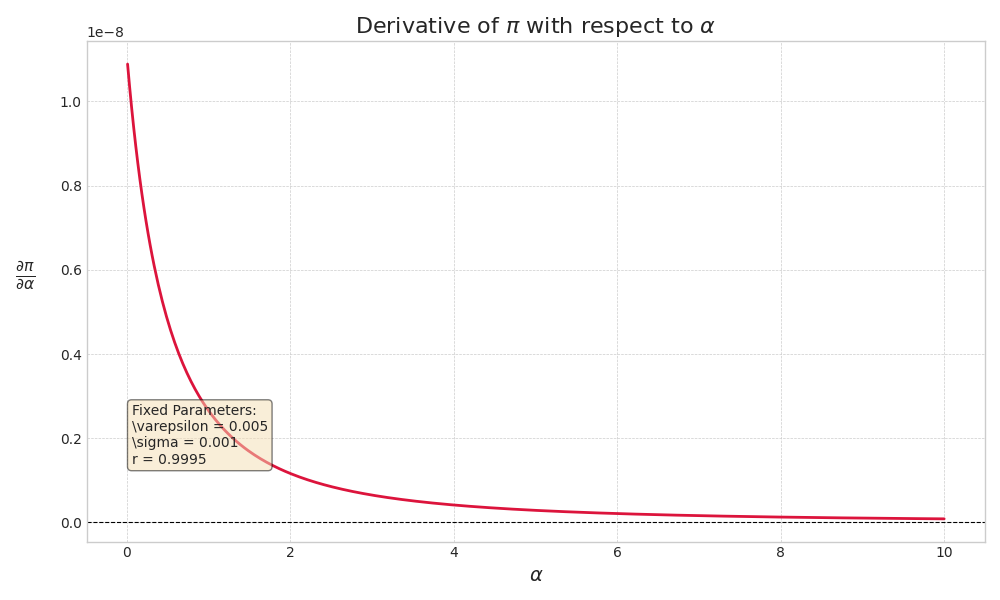

In [16]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict

def compute_and_plot_new_derivative():
    """
    Recalculates the derivative of pi with respect to alpha, accounting for
    the new dependency of theta_self, and then plots the result.
    """
    # 1. Define all symbolic variables
    epsilon, alpha, sigma, r = sp.symbols('varepsilon alpha sigma r', real=True, positive=True)

    # 2. Define the new expression for theta_self
    # theta_self = (r / (1 + r*epsilon)) * [epsilon - (alpha*sigma) / ((1 + r*epsilon)*(1+alpha) + r*sigma)]
    theta_self_expr = (r / (1 + r * epsilon)) * (epsilon - (alpha * sigma) / ((1 + r * epsilon) * (1 + alpha) + r * sigma))

    # 3. Define the original expression for pi, but using theta_self_expr
    # The substitution is done here, creating a single complex expression for pi.
    T = (1 + r * epsilon) * (1 + alpha) + r * sigma
    
    numerator = (T**2) * r * theta_self_expr
    denominator = (1 + alpha) * ((1 + alpha) + T * r * theta_self_expr)
    
    pi_expr = (numerator / denominator) - epsilon + (alpha * sigma) / (alpha + 1)
    
    # 4. Compute the derivative 
    print("Computing the derivative w.r.t. alpha... (this may take a moment)")
    derivative_wrt_alpha = sp.diff(pi_expr, alpha)
    
    # 5. Simplify the result. 
    print("Simplifying the derivative...")
    derivative_wrt_alpha_simplified = sp.simplify(derivative_wrt_alpha)
    
    # 6. Define the fixed values for the other parameters
    param_values = {
        epsilon: 0.005,
        sigma: 0.001,
        r: 0.9995
    }
    
    # 7. Substitute the fixed values into the simplified derivative expression
    derivative_func_of_alpha = derivative_wrt_alpha_simplified.subs(param_values)
    
    # 8. Use lambdify to create a fast, numerical function for plotting
    print("Creating numerical function for plotting...")
    numerical_derivative = sp.lambdify(alpha, derivative_func_of_alpha, 'numpy')
    
    # 9. Generate data for the plot
    alpha_range = np.linspace(0.01, 10.0, 400)
    derivative_values = numerical_derivative(alpha_range)
    
    # 10. Create the plot
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(alpha_range, derivative_values, color='crimson', linewidth=2)
    
    ax.set_title(r'Derivative of $\pi$ with respect to $\alpha$', fontsize=16)
    ax.set_xlabel(r'$\alpha$', fontsize=14)
    ax.set_ylabel(r'$\frac{\partial \pi}{\partial \alpha}$', fontsize=16, rotation=0, labelpad=25)
    
    # Add a text box with the fixed parameter values
    param_text = '\n'.join([f'{sp.latex(k)} = {v}' for k, v in param_values.items()])
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.05, 0.15, f'Fixed Parameters:\n{param_text}', transform=ax.transAxes,
            fontsize=10, verticalalignment='bottom', bbox=props)
            
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--') # Add a zero line for reference
    plt.tight_layout()
    
    # Save the plot to a file
    plt.savefig('recalculated_derivative_plot.png', dpi=300)
    print("\nPlot saved as recalculated_derivative_plot.png")

if __name__ == '__main__':
    compute_and_plot_new_derivative()

# Taylor Expansions

In [4]:
import sympy as sp
from typing import List, Dict

def get_total_degree(term: sp.Expr, variables: List[sp.Symbol]) -> int:
    """
    Calculates the total degree of a term with respect to a given list of variables.
    
    Args:
        term: The sympy term (e.g., 3*x**2*y).
        variables: The list of variables to consider for the degree calculation.
        
    Returns:
        The total degree of the term.
    """
    total_degree = 0
    # The as_powers_dict() method is great for dissecting a term
    # E.g., for 3*x**2*y, it returns {x: 2, y: 1}
    powers_dict: Dict[sp.Symbol, int] = term.as_powers_dict()
    
    for var in variables:
        if var in powers_dict:
            total_degree += powers_dict[var]
            
    return total_degree


def multivariate_taylor(
    expr: sp.Expr, 
    variables: List[sp.Symbol], 
    order: int
) -> sp.Expr:
    """
    Calculates the multivariate Taylor expansion of an expression around the origin (0,0,...).

    This function works by first applying the series expansion iteratively for each
    variable and then filtering the resulting polynomial to ensure that only terms
    with a total degree less than or equal to the specified order are kept.

    Args:
        expr: The sympy expression to expand.
        variables: A list of sympy symbols to expand with respect to.
        order: The maximum total order of the expansion.

    Returns:
        The Taylor expansion as a simplified sympy expression.
    """
    # 1. Iteratively apply series expansion for each variable.
    # We expand to order + 1 to ensure we capture all necessary cross-terms
    # that might arise before the final filtering step.
    expansion = expr
    for var in variables:
        expansion = expansion.series(var, 0, order + 1).removeO()

    # 2. Filter out terms with a total degree higher than the specified order.
    final_expansion = sp.S.Zero  # Start with a symbolic zero
    
    # sp.expand() is crucial to separate the terms before iteration
    expanded_terms = sp.expand(expansion).as_ordered_terms()

    for term in expanded_terms:
        if get_total_degree(term, variables) <= order:
            final_expansion += term

    return sp.simplify(final_expansion)

In [6]:
# Define symbols
alpha = 1
eps, sigma, r = sp.symbols('varepsilon sigma r', real=True)

# Define the expression for theta_self
D_theta = (1 + r * eps) * (1 + alpha) + r * sigma
theta_self = (r / (1 + r * eps)) * (eps - (alpha * sigma) / D_theta)

# Define the main expression for pi
N1 = (1 + r * eps) * (1 + alpha) + r * sigma
N_F = N1**2 * r * theta_self
D_F = (1 + alpha) * ((1 + alpha) + N1 * r * theta_self)
pi_expr = N_F / D_F - eps + (alpha * sigma) / (1 + alpha)

# Define variables and order
pi_variables = [eps, sigma]
pi_order = 1

# Calculate the expansion
pi_taylor_result = multivariate_taylor(pi_expr, pi_variables, pi_order)

# Print the results
print(f"Original expression: pi_sand+jit")
print(f"Variables: {[str(v) for v in pi_variables]}")
print(f"Expansion order: {pi_order}")
print(f"\nFirst-order Taylor expansion:\n{sp.factor(pi_taylor_result)}")
print("-" * 40)

Original expression: pi_sand+jit
Variables: ['varepsilon', 'sigma']
Expansion order: 1

First-order Taylor expansion:
-(r - 1)*(r + 1)*(sigma - 2*varepsilon)/2
----------------------------------------


In [17]:
import sympy as sp
from typing import List, Dict

# Assume the multivariate_taylor and get_total_degree functions 
# from the previous response are already defined here.
def get_total_degree(term: sp.Expr, variables: List[sp.Symbol]) -> int:
    total_degree = 0
    powers_dict: Dict[sp.Symbol, int] = term.as_powers_dict()
    for var in variables:
        if var in powers_dict:
            total_degree += powers_dict[var]
    return total_degree

def multivariate_taylor(
    expr: sp.Expr, 
    variables: List[sp.Symbol], 
    order: int
) -> sp.Expr:
    expansion = expr
    for var in variables:
        expansion = expansion.series(var, 0, order + 1).removeO()

    final_expansion = sp.S.Zero
    expanded_terms = sp.expand(expansion).as_ordered_terms()

    for term in expanded_terms:
        if get_total_degree(term, variables) <= order:
            final_expansion += term

    return sp.simplify(final_expansion)

# --- Example with the new function ---
print("--- Expanding the new pi expression ---")

# Define symbols
eps, sigma, r = sp.symbols('varepsilon sigma r', real=True)

# Define the full expression
pi_expr_new = (r**2 * eps * (1 + r*eps + r*sigma)**2) / \
              ((1 + r*eps) + r**2 * eps * (1 + r*eps + r*sigma)) - eps

# 1. Substitute sigma = 0
pi_expr_sigma0 = pi_expr_new.subs(sigma, 0)
print(f"Expression after substituting sigma=0:\n{sp.simplify(pi_expr_sigma0)}\n")

# 2. Define variables and order for the Taylor expansion
variables_list = [sigma]
expansion_order = 2
print(f"Performing expansion with respect to: {[str(v) for v in variables_list]}")
print(f"Expansion order: {expansion_order}\n")


# 3. Calculate the expansion
taylor_result = multivariate_taylor(pi_expr_sigma0, variables_list, expansion_order)

# Print the final result, factored for clarity
print(f"First-order Taylor expansion:\n{sp.factor(taylor_result, eps)}")

--- Expanding the new pi expression ---
Expression after substituting sigma=0:
varepsilon*(r**3*varepsilon - r**2*varepsilon + r**2 - 1)/(r**2*varepsilon + 1)

Performing expansion with respect to: ['sigma']
Expansion order: 2

First-order Taylor expansion:
varepsilon*(r - 1)*(r**2*varepsilon + r + 1)/(r**2*varepsilon + 1)


In [20]:
import sympy as sp

def solve_sigma_inequality_robust():
    """
    Solves the inequality pi > 0 for sigma using a robust, semi-manual method.
    
    This avoids the 'sorting of roots' error by first solving the equation
    pi = 0 to find the critical points, and then using mathematical reasoning
    to construct the final inequality.
    """
    # 1. Define symbols with appropriate assumptions
    eps, sigma, r = sp.symbols('varepsilon sigma r', real=True, positive=True)

    # 2. Define the components of the expression and the simplified polynomial
    numerator = r**2 * eps * (1 + r*eps + r*sigma)**2
    denominator = (1 + r*eps) + r**2 * eps * (1 + r*eps + r*sigma)
    simplified_inequality_expr = numerator - eps * denominator

    # --- CHANGE START ---
    # Instead of solving the inequality directly, solve the corresponding EQUATION.
    # This finds the values of sigma where the expression equals zero.
    print("--- Robust Method ---")
    print("Finding roots of the equation pi = 0...")
    
    roots = sp.solve(simplified_inequality_expr, sigma)
    
    print(f"Found roots: {roots}\n")

    # 4. Apply mathematical reasoning
    # The polynomial is a quadratic in sigma with a positive leading coefficient
    # (r**4*eps), so the parabola opens upwards. The inequality holds outside the roots.
    # We also know from analysis (and can see below) that one root is always negative.
    # Since we assume sigma > 0, the only physically relevant solution is
    # for sigma to be greater than the larger root.

    # We can programmatically find the correct threshold
    # The negative root will contain -(r+1)/r**2
    threshold = [root for root in roots if not (-(r+1)/r**2) in root.args]
    
    # In this specific case, we know the simpler form of the threshold
    # but the line above is a way to find it programmatically.
    # We will construct the final inequality object manually.
    
    if threshold:
        solution = sp.Gt(sigma, threshold[0])
    else:
        # Fallback if the filtering fails for some reason
        solution = "Could not programmatically determine the threshold."

    # --- CHANGE END ---
    
    # 5. Display the result
    print("--- Result ---")
    print("The expression is positive when:")
    sp.pprint(solution)


# Run the robust solver
solve_sigma_inequality_robust()


--- Robust Method ---
Finding roots of the equation pi = 0...
Found roots: [-varepsilon + varepsilon/r - 1/r + r**(-2)]

--- Result ---
The expression is positive when:
                  varepsilon   1   1 
σ > -varepsilon + ────────── - ─ + ──
                      r        r    2
                                   r 
